# MNIST Classification

## Loading necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers


2026-03-12 17:45:58.441647: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773337558.750000      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773337558.846049      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773337559.688282      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773337559.688330      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773337559.688333      55 computation_placer.cc:177] computation placer alr

## Loading Data

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Exploring Data

Training set shape: (60000, 28, 28) (60000,)
Test set shape: (10000, 28, 28) (10000,)
Pixel value range: 0 - 255


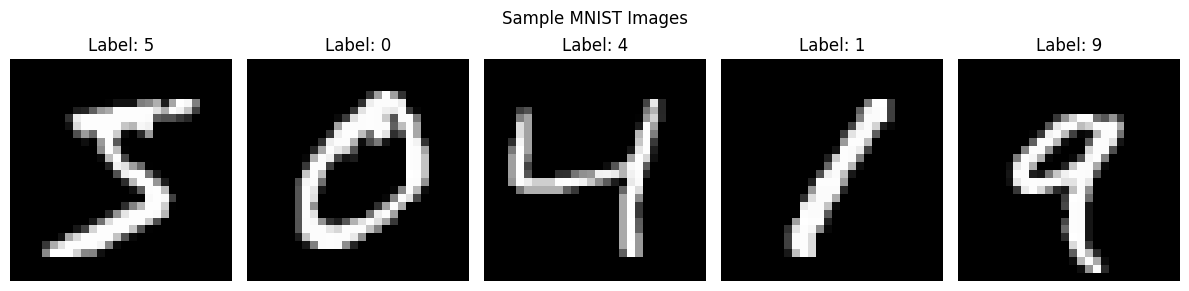

In [3]:
# Explore the data
print("Training set shape:", x_train.shape, y_train.shape)
print("Test set shape:", x_test.shape, y_test.shape)
print("Pixel value range:", x_train.min(), "-", x_train.max())

# Show a few sample images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

## Preprocesing

In [4]:
# Step 1: Preprocess the data
# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Preprocessed shapes:", x_train.shape, x_test.shape)

Preprocessed shapes: (60000, 784) (10000, 784)


## Model Building

In [5]:
# Step 2: Build a simple neural network model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-12 17:46:20.689014: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compiling

In [6]:
# early stopping and learning rate reduction
# callbacks libraries
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)


In [7]:
# Step 3: Compile the model
# Define callbacks

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

callbacks = [reduce_lr, early_stopping]
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    
)


## Training

In [8]:
# Step 4: Train the model
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks
)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8682 - loss: 0.4398 - val_accuracy: 0.9692 - val_loss: 0.1050 - learning_rate: 0.0010
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9653 - loss: 0.1098 - val_accuracy: 0.9743 - val_loss: 0.0894 - learning_rate: 0.0010
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9775 - loss: 0.0730 - val_accuracy: 0.9762 - val_loss: 0.0820 - learning_rate: 0.0010
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9836 - loss: 0.0529 - val_accuracy: 0.9763 - val_loss: 0.0873 - learning_rate: 0.0010
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9876 - loss: 0.0388 - val_accuracy: 0.9768 - val_loss: 0.0818 - learning_rate: 0.0010
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9900 - loss: 0.0308 - val_accuracy: 0.9793 - val_loss: 0.0834 - learning_rate: 0.0010
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9903 - l

## Evaluation

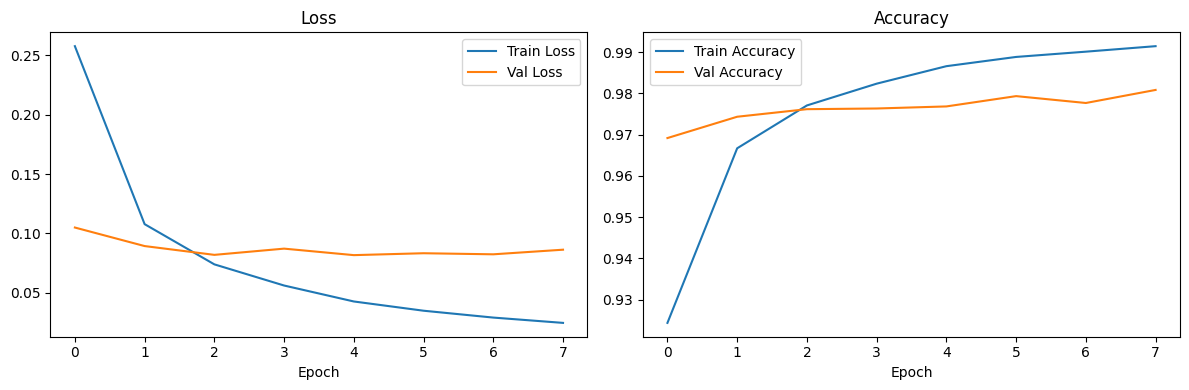

In [12]:
# Step 5: Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [13]:
# Step 6: Evaluate on test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0847
Test Accuracy: 0.9756


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


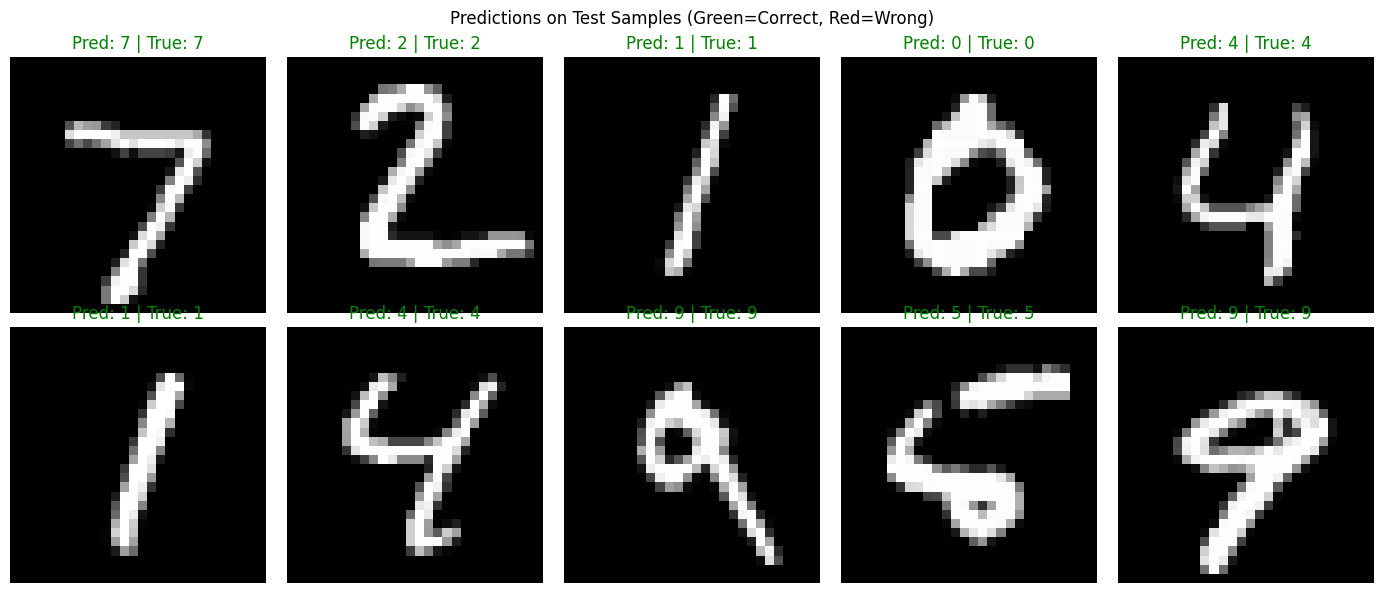

In [14]:
# Step 7: Make predictions and visualize results
predictions = model.predict(x_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if predicted_labels[i] == y_test[i] else 'red'
    ax.set_title(f"Pred: {predicted_labels[i]} | True: {y_test[i]}", color=color)
    ax.axis('off')
plt.suptitle("Predictions on Test Samples (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()